In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1. SETUP & CONFIG
warnings.filterwarnings("ignore")

class Config:
    DATA_PATH = "C:\\Kuliah\\Skripsi\\Projek Skripsi\\utmb_with_weather_data.csv"
    OUT_DIR = "C:\\Kuliah\\Skripsi\\Projek Skripsi\\output_Skripsi_Final_Lengkap"
    RANDOM_STATE = 42
    PILOT_FRAC = 1.0  
    SPLIT_SCENARIOS = [0.2, 0.3, 0.1] # Test: 20%, 30%, 10%
    TOP_N = 10
    CV_SPLITS = 5
    TREE_METHOD = "hist"
    ENABLE_LOG_TARGET = True
    N_STRATA_BINS = 10
    N_ITER_SEARCH = 10 
    SCORING = "neg_mean_absolute_percentage_error"
    SAVE_FIG_DPI = 300

os.makedirs(Config.OUT_DIR, exist_ok=True)
log = lambda msg: print(f"[INFO] {msg}")

In [2]:
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

def compute_metrics(y_true, y_pred):
    """Menghitung metrik evaluasi utama."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE(%)": mean_absolute_percentage_error(y_true, y_pred) * 100
    }

def fwd_log(x): return np.log(np.asarray(x, float))
def inv_exp(x): return np.exp(np.asarray(x, float))
def fwd_none(x): return np.asarray(x, float)
def inv_none(x): return np.asarray(x, float)

class TransformedTargetEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, regressor, fwd=None, inv=None):
        self.regressor, self.fwd, self.inv = regressor, fwd, inv
    def fit(self, X, y):
        y_t = self.fwd(y) if self.fwd else y
        self.regressor_ = clone(self.regressor).fit(X, y_t)
        return self
    def predict(self, X):
        y_pred_t = self.regressor_.predict(X)
        return self.inv(y_pred_t) if self.inv else y_pred_t
    def get_params(self, deep=True):
        params = {"regressor": self.regressor, "fwd": self.fwd, "inv": self.inv}
        if deep and hasattr(self.regressor, "get_params"):
            for k, v in self.regressor.get_params(deep=True).items(): params[f"regressor__{k}"] = v
        return params
    def set_params(self, **params):
        for k in list(params.keys()):
            if k in ("regressor", "fwd", "inv"): setattr(self, k, params.pop(k))
        if params: self.regressor.set_params(**{k.replace("regressor__", ""): v for k, v in params.items()})
        return self



In [3]:
# 3. PREPROCESSING & FEATURES

def clean_data(df):
    df = df.dropna(subset=["mean_finish_time"]).copy()
    df = df[(df["distance_km"] > 0) & (df["elevation_gain_m"] >= 0)]
    df["race_category"] = df["race_category"].fillna("Unknown")
    return df

def feature_engineering(df):
    df = df.copy()
    if "event_date" in df.columns:
        df["month"] = pd.to_datetime(df["event_date"], errors="coerce").dt.month
    df["km_effort"] = df["distance_km"] + (df["elevation_gain_m"] / 100.0)
    df["eg_per_km"] = df["elevation_gain_m"] / df["distance_km"]
    return df

def anti_leakage_filter(df):
    drop_cols = ["race_uid", "race_title", "raw_location", "winning_time", "Last Time", "N DNF", "event_date", "latitude", "longitude", "continent", "wx_rain_sum"]
    return df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

def get_scenario_feature_lists(X):
    wx = [c for c in ["wx_temp_max", "wx_temp_min", "wx_temp_mean", "wx_precip_sum", "wx_wind_speed"] if c in X.columns]
    base = [c for c in ["year", "day_of_year", "month", "distance_km", "elevation_gain_m", "elevation_variance", "n_participants", "n_women", "n_countries", "race_category", "km_effort", "eg_per_km"] if c in X.columns] + wx
    return list(dict.fromkeys(base)), [c for c in base if not c.startswith("wx_")], ["distance_km", "elevation_gain_m", "race_category", "month"]


In [4]:
# --- MODEL PIPELINE & TUNING (VERSI LO) ---
def build_pipeline(feature_list, random_state, tree_method):
    cat_cols = [c for c in ["race_category"] if c in feature_list]
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols)
    ])
    model = XGBRegressor(objective="reg:squarederror", random_state=random_state, n_jobs=-1, tree_method=tree_method, enable_categorical=False)
    return Pipeline([("pre", pre), ("model", model)]), cat_cols, num_cols

def tune_scenario_A(estimator, X_train, y_train_orig, strata_train, cfg: Config):
    param_distributions = {
        "regressor__model__learning_rate": [0.01, 0.05, 0.1],
        "regressor__model__n_estimators": [500, 1000, 1500],
        "regressor__model__max_depth": [4, 6, 8, 10],
        "regressor__model__min_child_weight": [1, 3, 5, 7, 10],
        "regressor__model__gamma": [0.0, 0.1, 0.2, 0.5],
        "regressor__model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "regressor__model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "regressor__model__reg_alpha": [0.0, 1e-4, 1e-3, 1e-2, 0.1, 1.0],
        "regressor__model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    }
    cv = StratifiedKFold(n_splits=cfg.CV_SPLITS, shuffle=True, random_state=cfg.RANDOM_STATE)
    search = RandomizedSearchCV(estimator, param_distributions, n_iter=cfg.N_ITER_SEARCH, scoring=cfg.SCORING, cv=cv.split(X_train, strata_train), verbose=1, random_state=cfg.RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train_orig)
    return search.best_estimator_, search.best_params_

def get_gain_importance(model_xgb, feature_names):
    gain_dict = model_xgb.get_booster().get_score(importance_type="gain")
    return pd.DataFrame([(feature_names[int(k.replace("f", ""))], gain) for k, gain in gain_dict.items() if 0 <= int(k.replace("f", "")) < len(feature_names)], columns=["feature", "gain"]).sort_values("gain", ascending=False)

def get_cv_per_fold_metrics(estimator, X, y, strata, cfg, model_name, split_label):
    """Mengevaluasi metrik stabilitas per fold."""
    skf = StratifiedKFold(n_splits=cfg.CV_SPLITS, shuffle=True, random_state=cfg.RANDOM_STATE)
    fold_results = []
    X_res = X.reset_index(drop=True)
    y_res = np.asarray(y)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_res, strata), 1):
        est = clone(estimator).fit(X_res.iloc[tr_idx], y_res[tr_idx])
        pred = est.predict(X_res.iloc[va_idx])
        m = compute_metrics(y_res[va_idx], pred)
        m.update({"Fold": fold, "Model": model_name, "Split": split_label})
        fold_results.append(m)
    return fold_results

In [5]:
def plot_lc(lc_df, path, title):
    plt.figure(figsize=(8, 4))
    plt.plot(lc_df["train_size"], lc_df["mape_train_mean(%)"], 'o-', label="Train", color='#4C72B0')
    plt.plot(lc_df["train_size"], lc_df["mape_val_mean(%)"], 'o-', label="Val", color='#C44E52')
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(path, dpi=300); plt.show(); plt.close()

def learning_curve_mape(estimator, X_train, y_train_orig, strata_train, cfg):
    train_fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
    skf = StratifiedKFold(n_splits=cfg.CV_SPLITS, shuffle=True, random_state=cfg.RANDOM_STATE)
    rows = []
    for frac in train_fracs:
        t_mapes, v_mapes = [], []
        for tr_idx, va_idx in skf.split(X_train, strata_train):
            m = max(10, int(len(tr_idx) * frac))
            sub_idx = tr_idx[:m]
            est = clone(estimator).fit(X_train.iloc[sub_idx], y_train_orig[sub_idx])
            t_mapes.append(mean_absolute_percentage_error(y_train_orig[sub_idx], est.predict(X_train.iloc[sub_idx])) * 100)
            v_mapes.append(mean_absolute_percentage_error(y_train_orig[va_idx], est.predict(X_train.iloc[va_idx])) * 100)
        rows.append({"train_size": int(len(X_train) * frac), "mape_train_mean(%)": np.mean(t_mapes), "mape_val_mean(%)": np.mean(v_mapes)})
    return pd.DataFrame(rows)


def run_dual_shap(model, X_encoded, f_names, split_label, model_name, cfg):
    explainer = shap.TreeExplainer(model)
    shap_v = explainer.shap_values(X_encoded)
    # Bar Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_v, X_encoded, feature_names=f_names, plot_type="bar", show=False, color='#4C72B0')
    plt.title(f"SHAP Bar Plot - {model_name} ({split_label})", pad=20, fontweight='bold')
    plt.savefig(f"{cfg.OUT_DIR}/SHAP_Bar_{model_name}_{split_label}.png", bbox_inches="tight", dpi=cfg.SAVE_FIG_DPI); plt.show(); plt.close()
    # Beeswarm
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_v, X_encoded, feature_names=f_names, show=False)
    plt.title(f"SHAP Beeswarm Plot - {model_name} ({split_label})", pad=20, fontweight='bold')
    plt.savefig(f"{cfg.OUT_DIR}/SHAP_Beeswarm_{model_name}_{split_label}.png", bbox_inches="tight", dpi=cfg.SAVE_FIG_DPI); plt.show(); plt.close()

def plot_model_comparison_grid(y_true, predictions_dict, title_prefix, out_path, dpi, is_residual=False):
    dir_name, file_name = os.path.split(out_path)
    for model_name, y_pred in predictions_dict.items():
        plt.figure(figsize=(7, 6))
        if not is_residual:
            plt.scatter(y_true, y_pred, s=10, alpha=0.5, color='#4C72B0')
            # PERBAIKAN: Gunakan np.min(y_true) bukan y_all
            mn, mx = float(np.min(y_true)), float(np.max(y_true))
            plt.plot([mn, mx], [mn, mx], color='red', linestyle='--')
            plt.title(f"{model_name}\n({title_prefix})")
            plt.xlabel("Actual (hours)"); plt.ylabel("Prediction (hours)")
        else:
            resid = np.asarray(y_true) - np.asarray(y_pred)
            plt.hist(resid, bins=40, color='#55A868', edgecolor='black', alpha=0.7)
            plt.title(f"Residual: {model_name}\n({title_prefix})")
            plt.xlabel("Error"); plt.ylabel("Frequency"); plt.axvline(0, color='red', linestyle='--')
        
        plt.grid(True, linestyle=':', alpha=0.6); plt.tight_layout()
        safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "")
        plt.savefig(os.path.join(dir_name, f"{safe_name}_{os.path.basename(out_path)}"), dpi=dpi, bbox_inches="tight")
        plt.show(); plt.close()

[INFO] 🚀 Memulai Eksperimen Final Boss...
[INFO] 
RUNNING SPLIT 80:20
[INFO] Training Model A...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


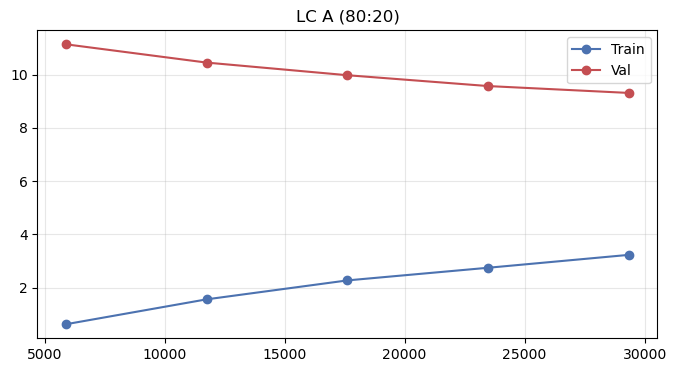

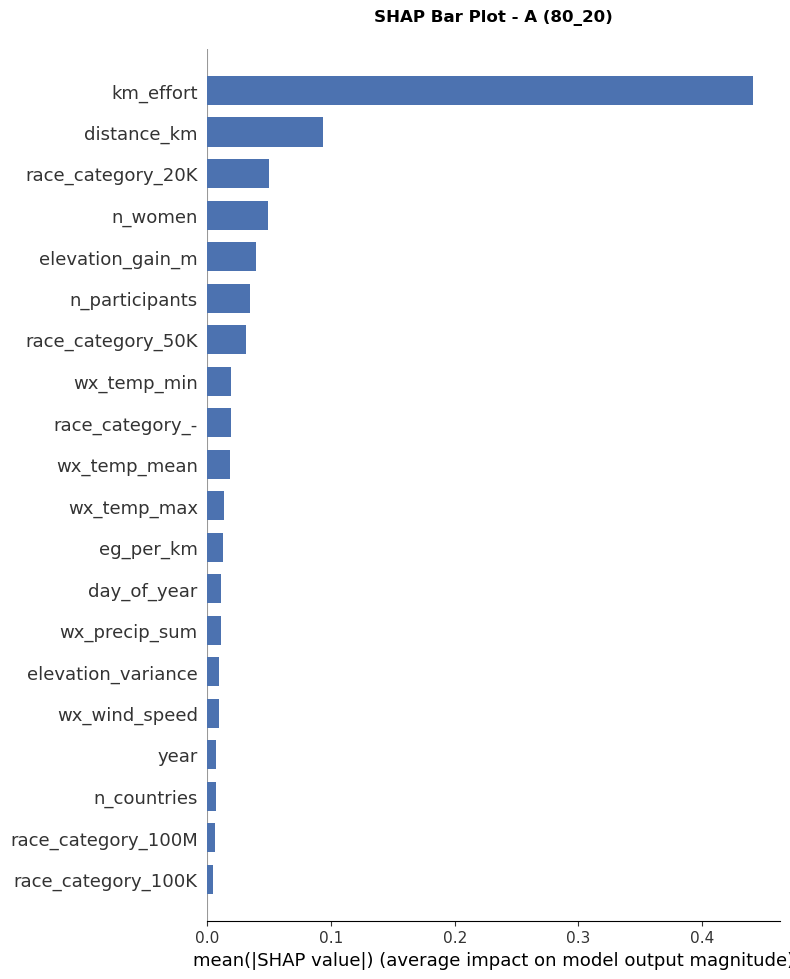

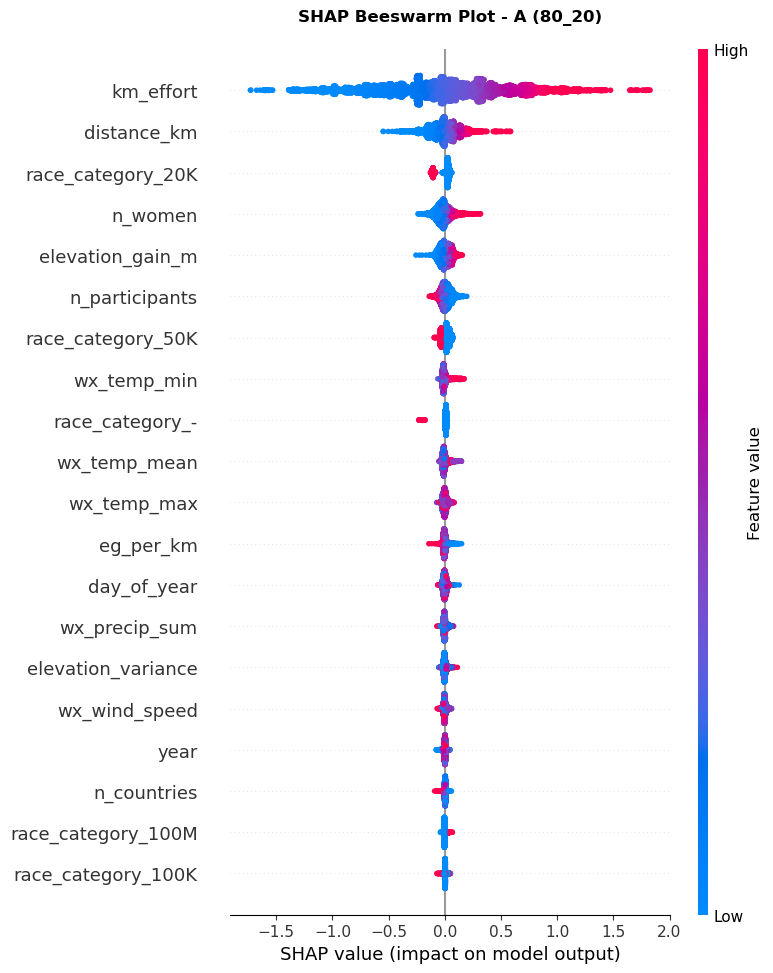

[INFO] Training Model B...


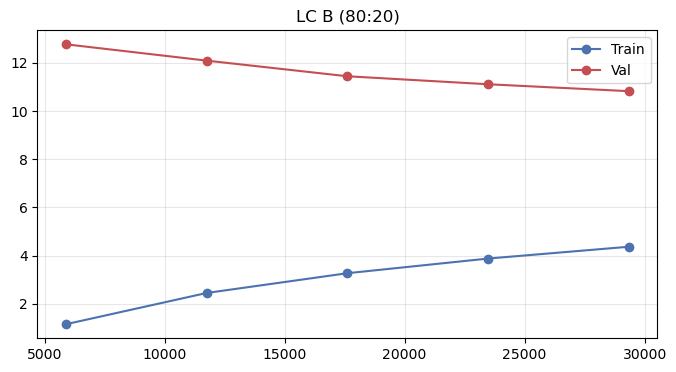

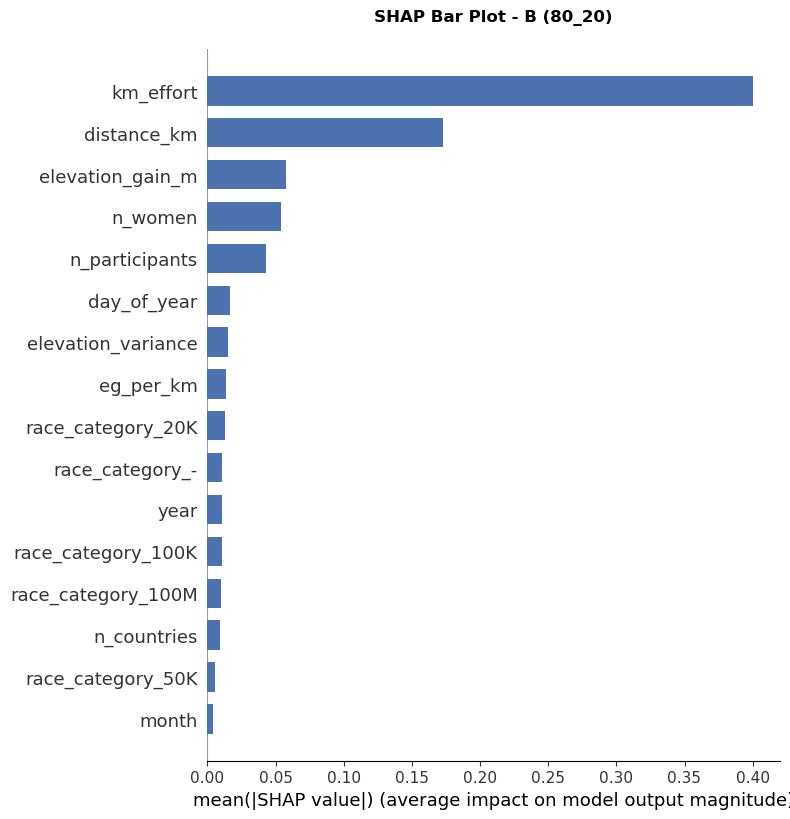

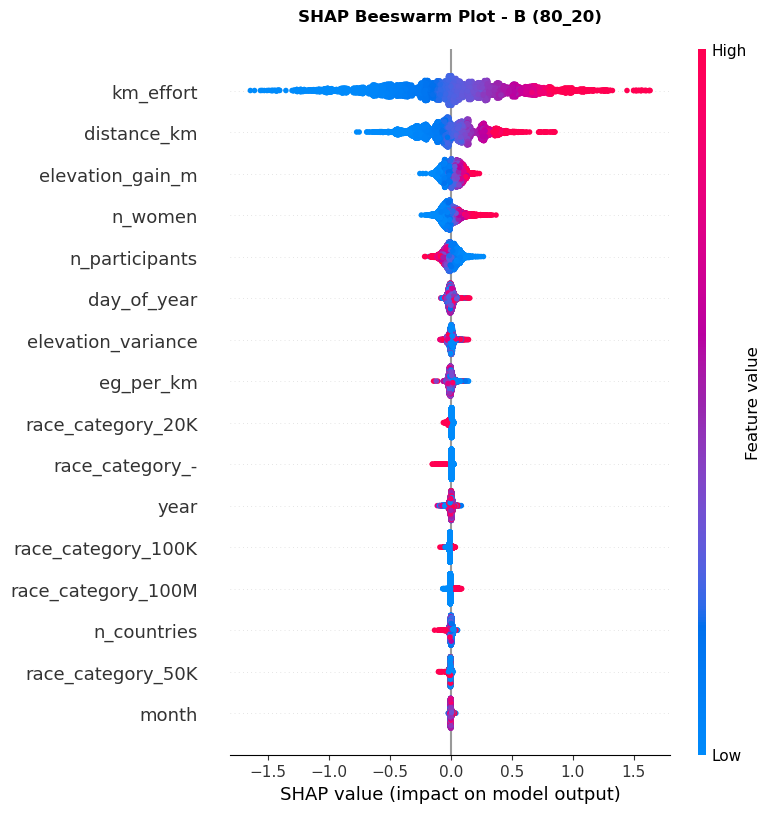

[INFO] Training Model D...


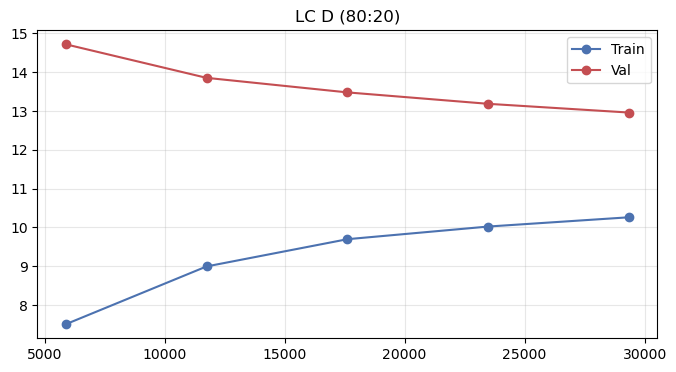

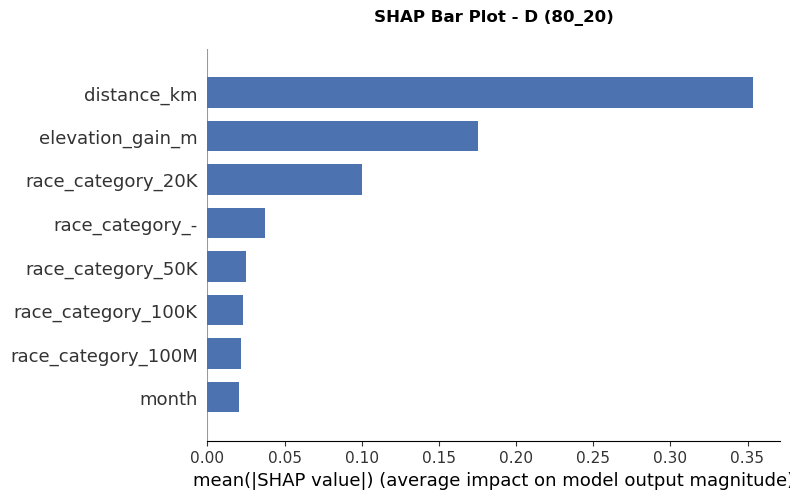

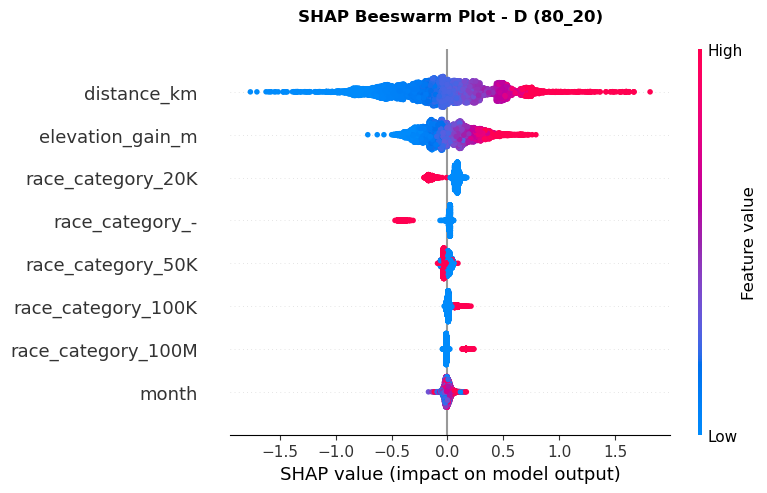

[INFO] Training Model C...


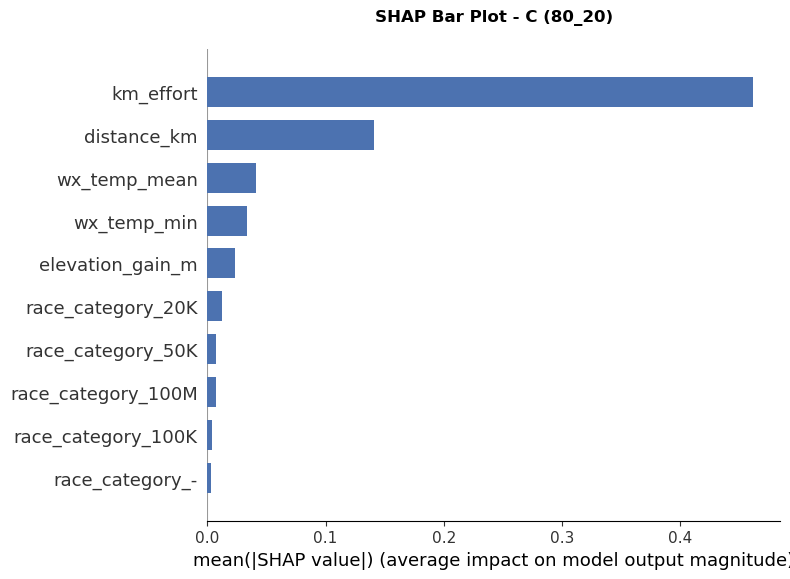

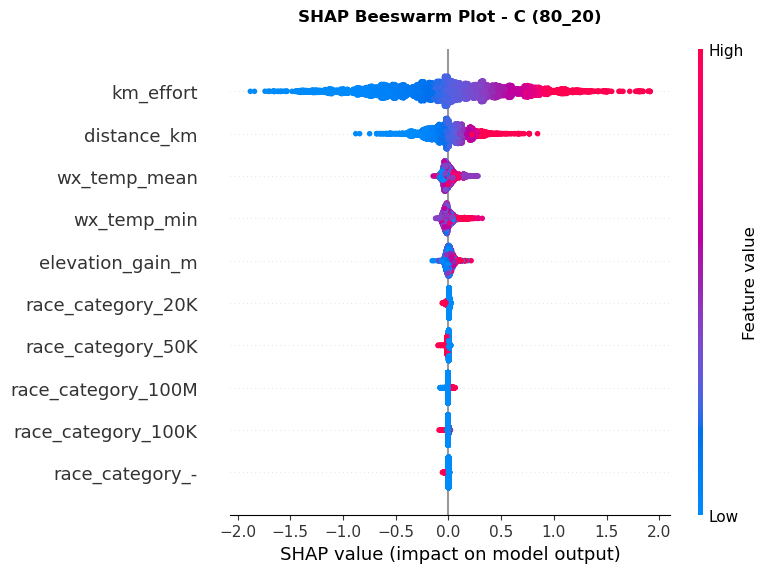

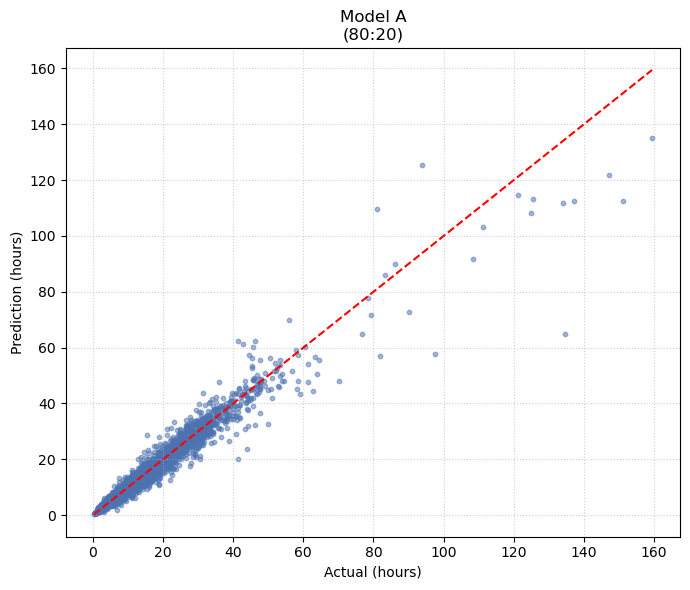

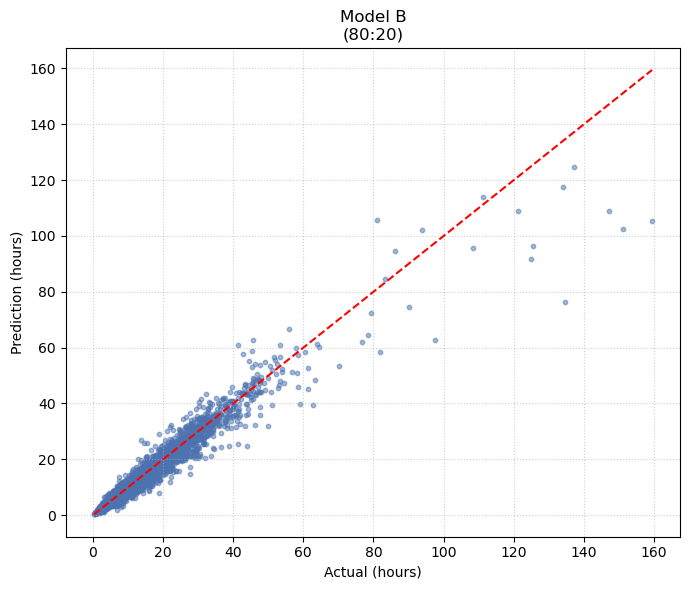

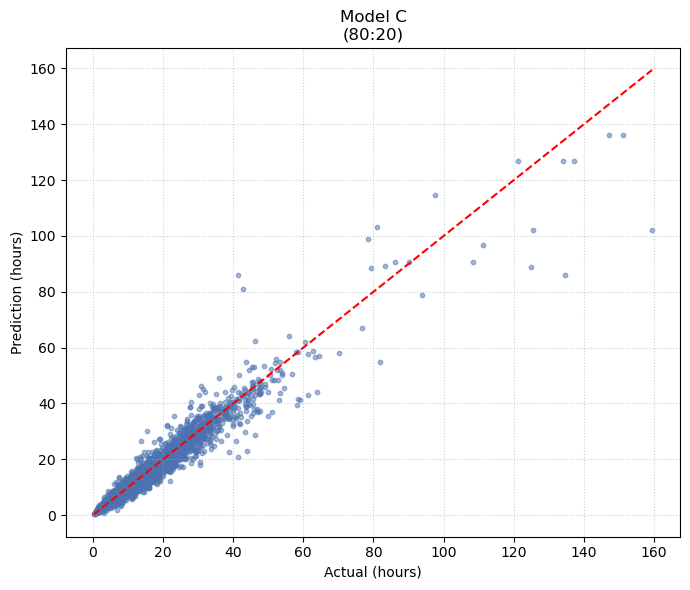

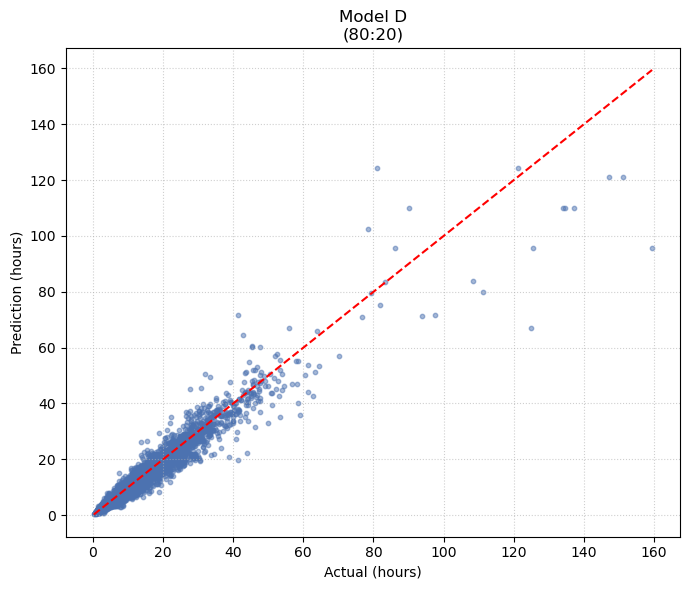

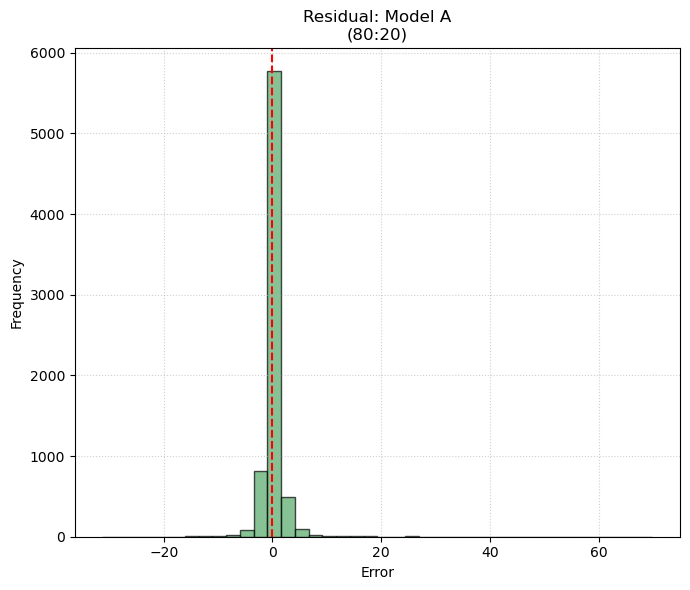

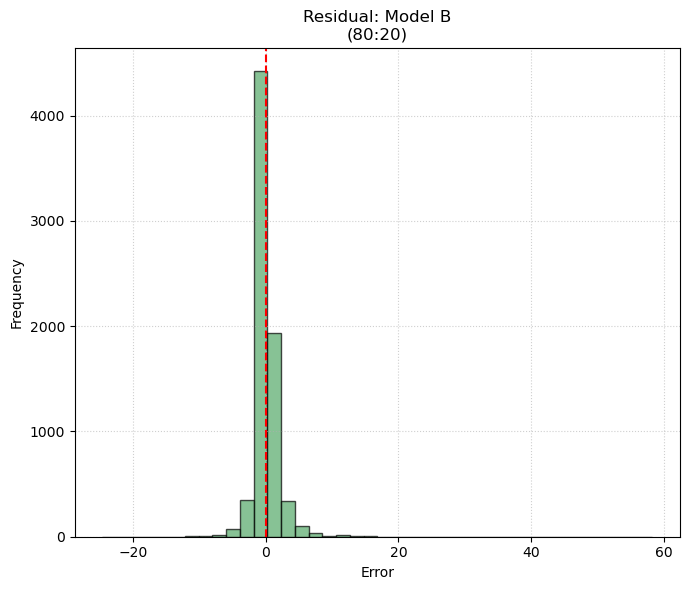

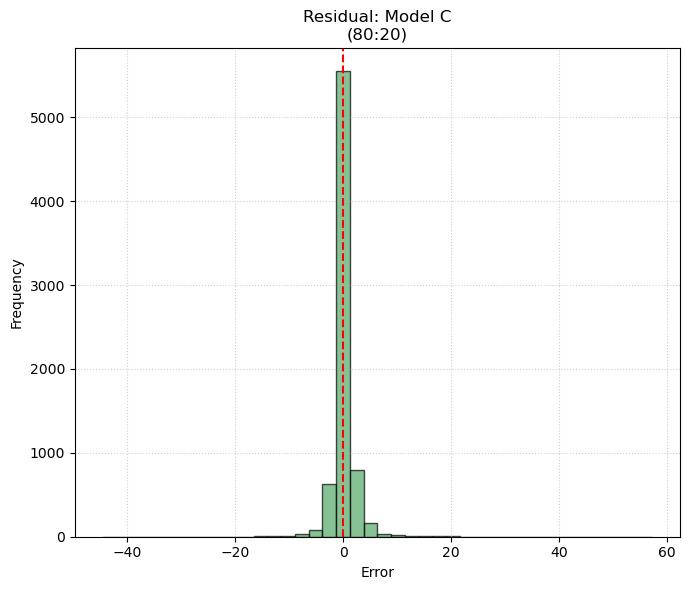

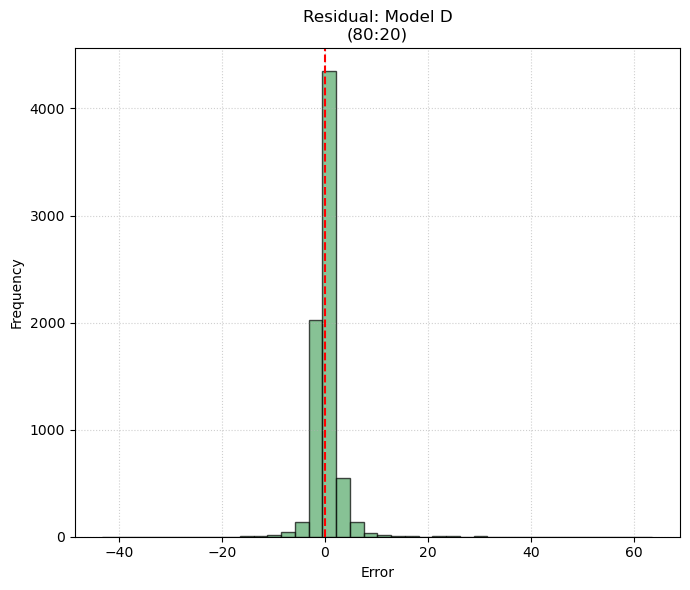

[INFO] 
RUNNING SPLIT 70:30
[INFO] Training Model A...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


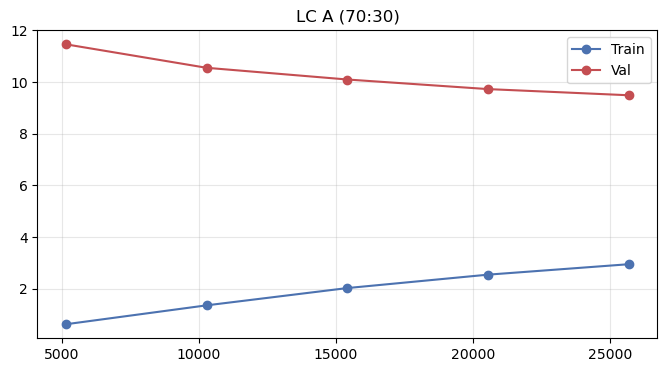

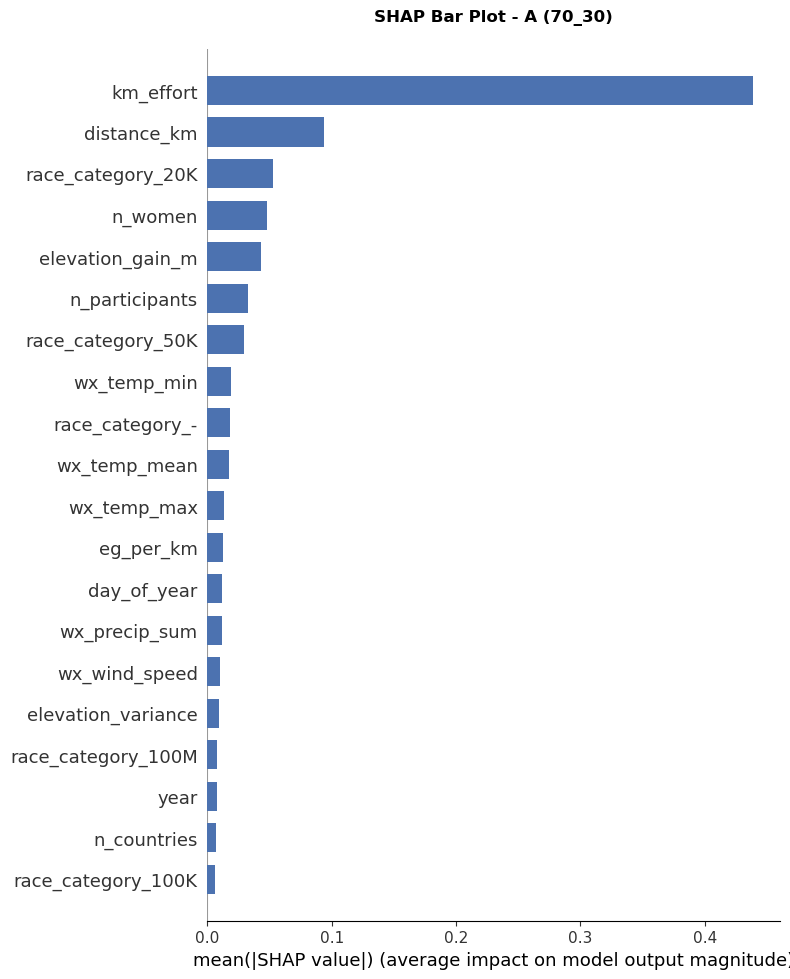

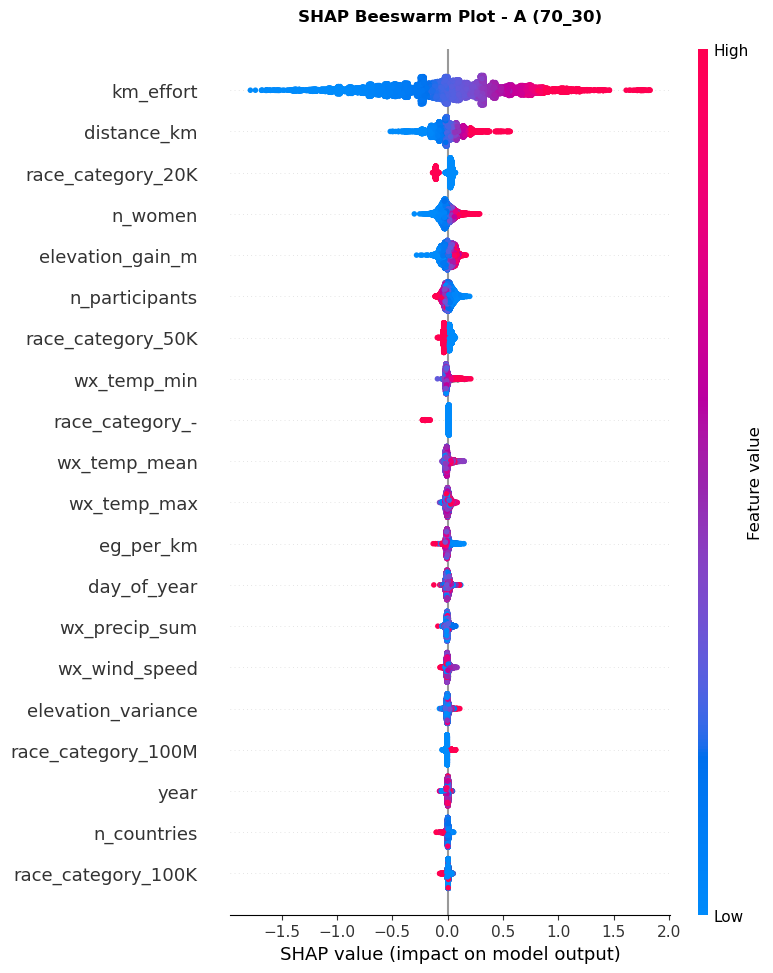

[INFO] Training Model B...


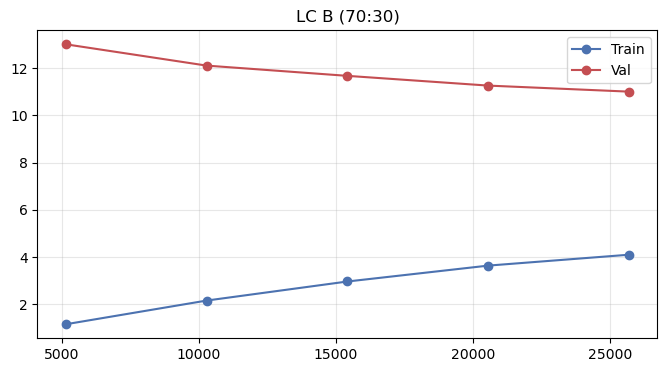

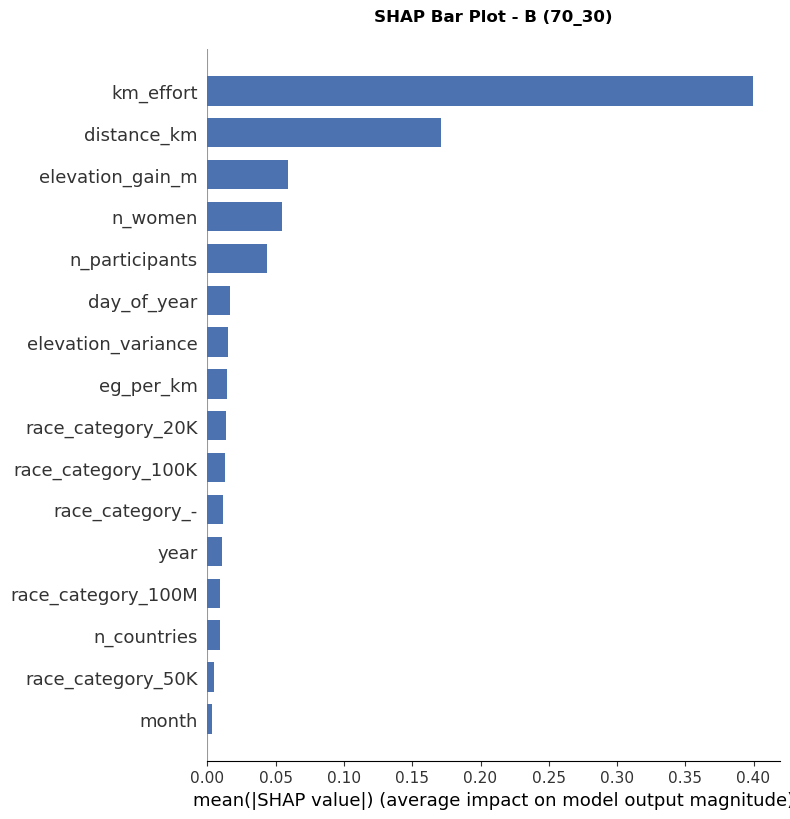

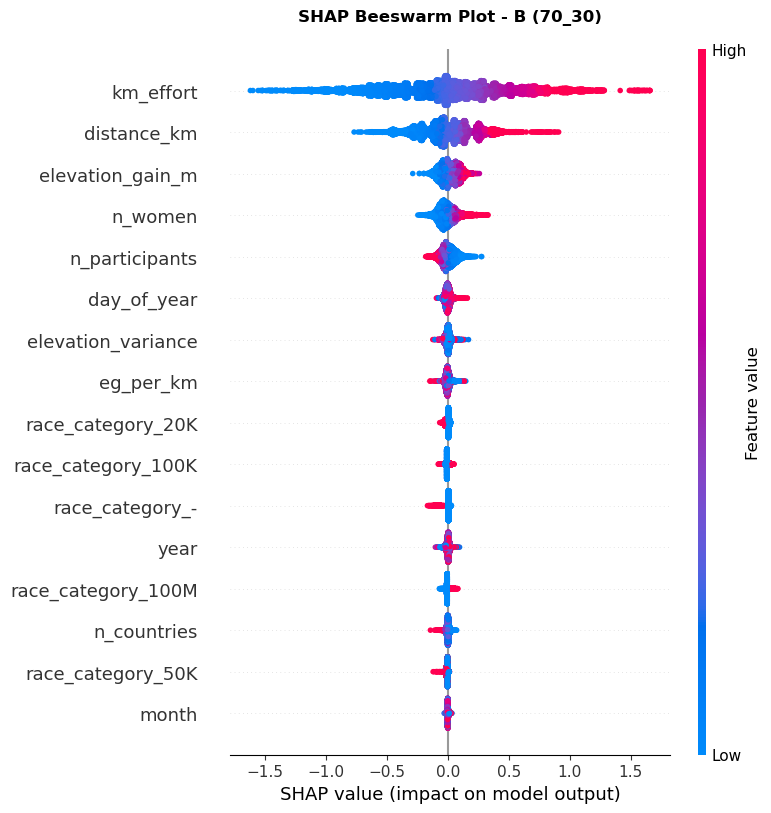

[INFO] Training Model D...


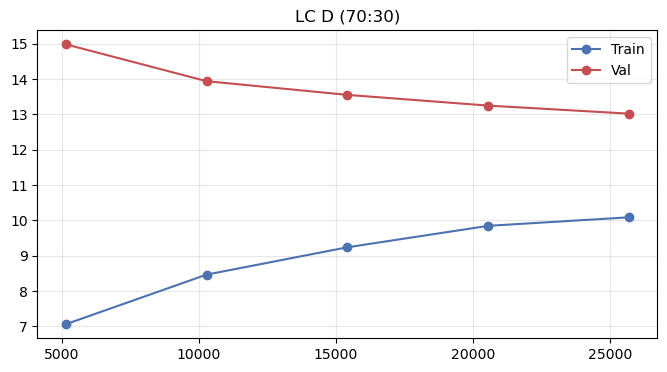

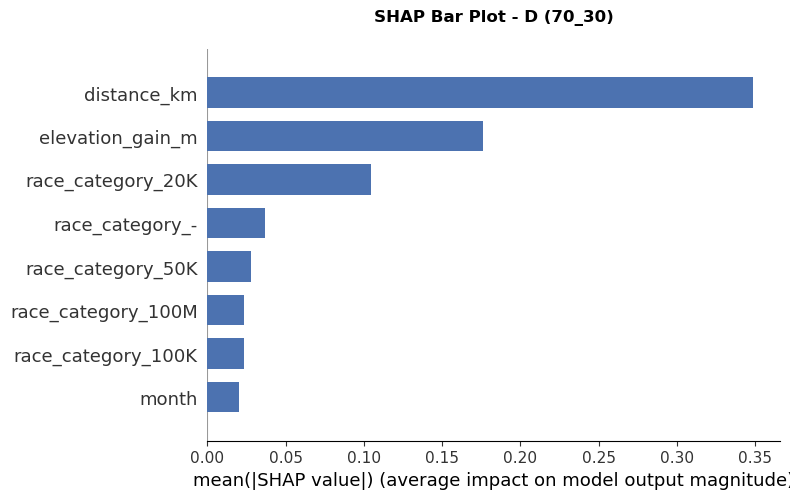

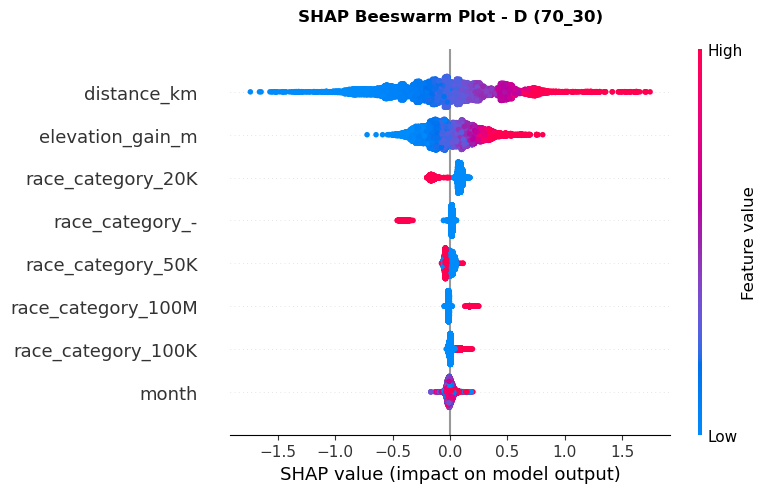

[INFO] Training Model C...


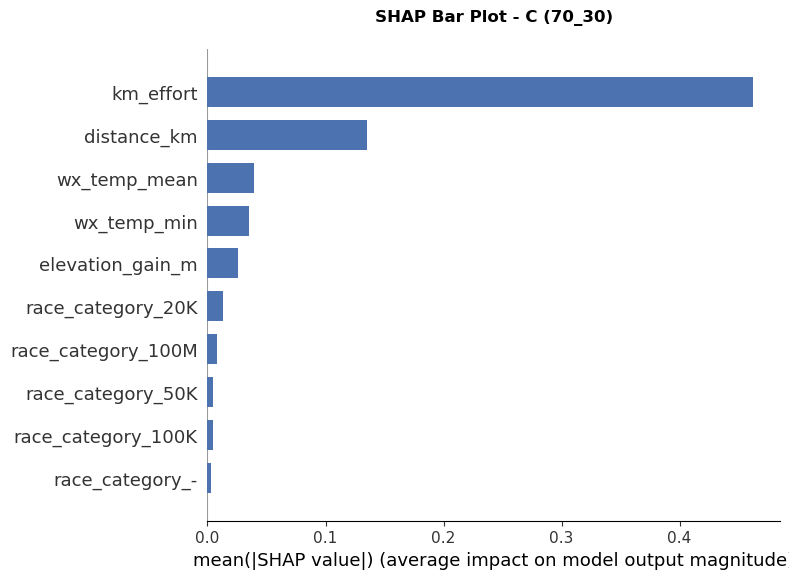

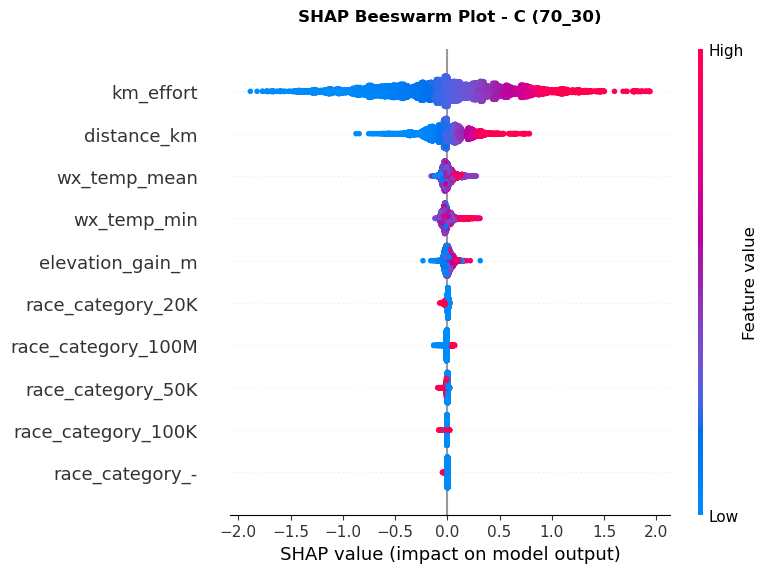

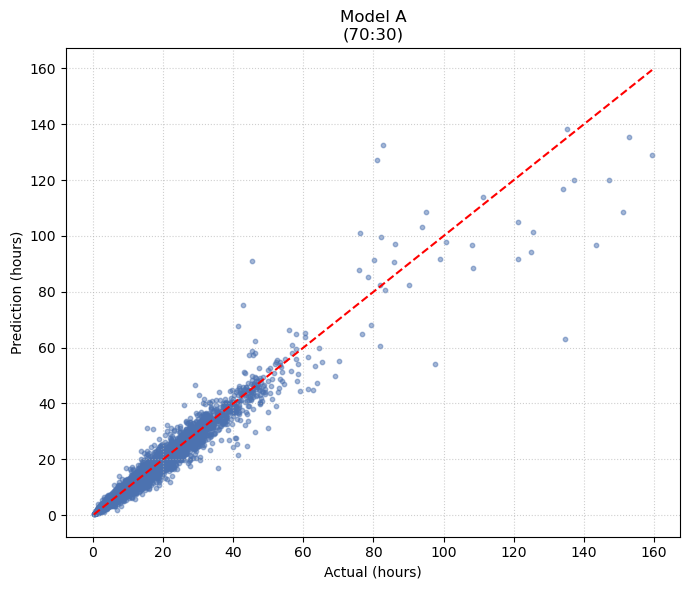

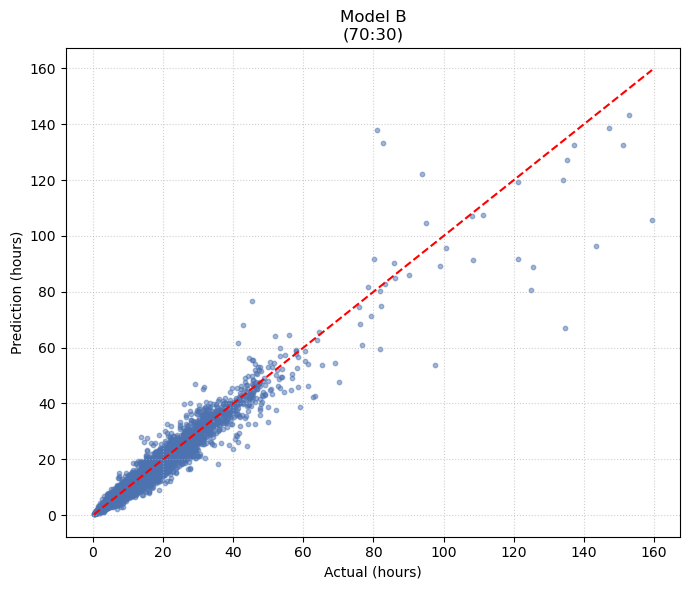

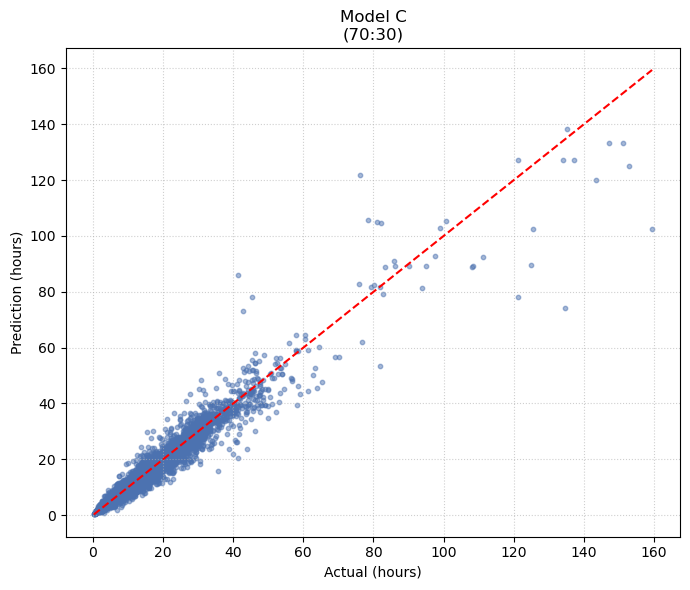

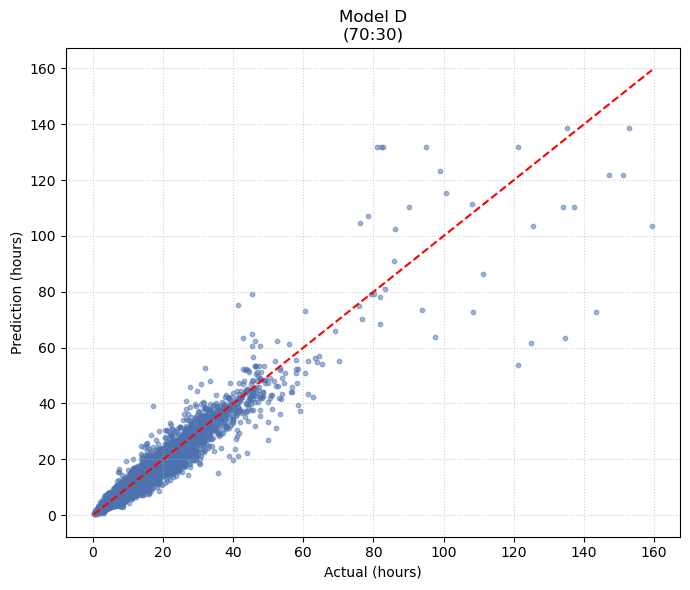

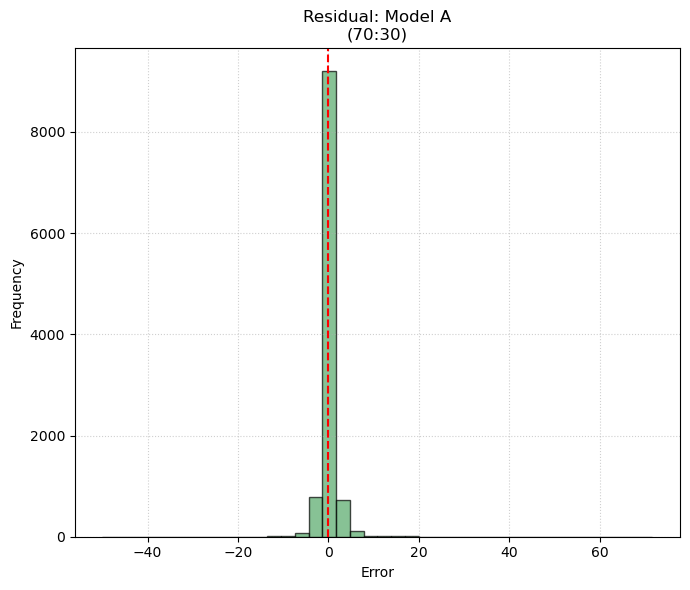

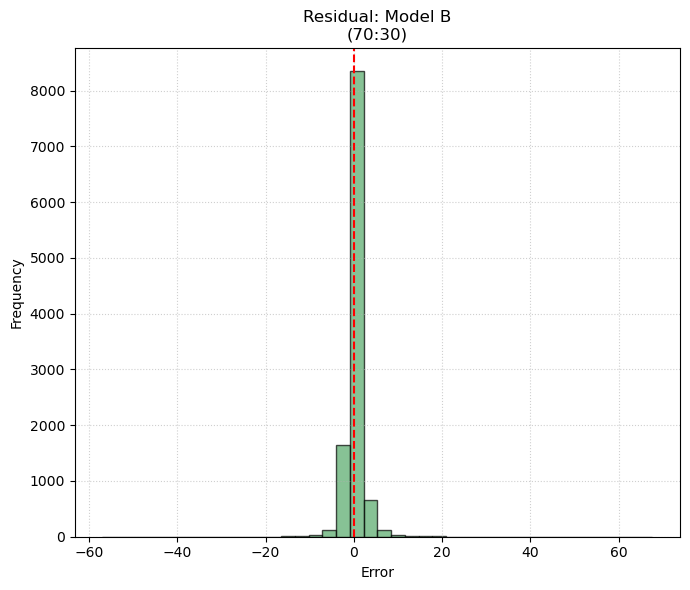

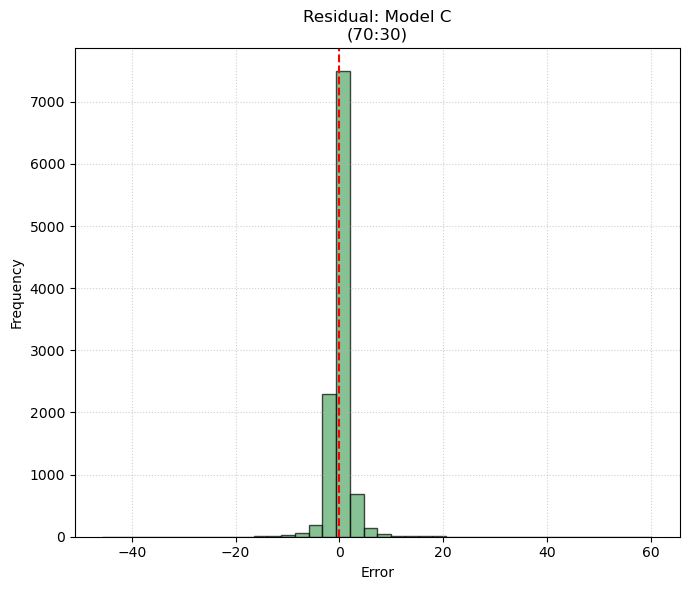

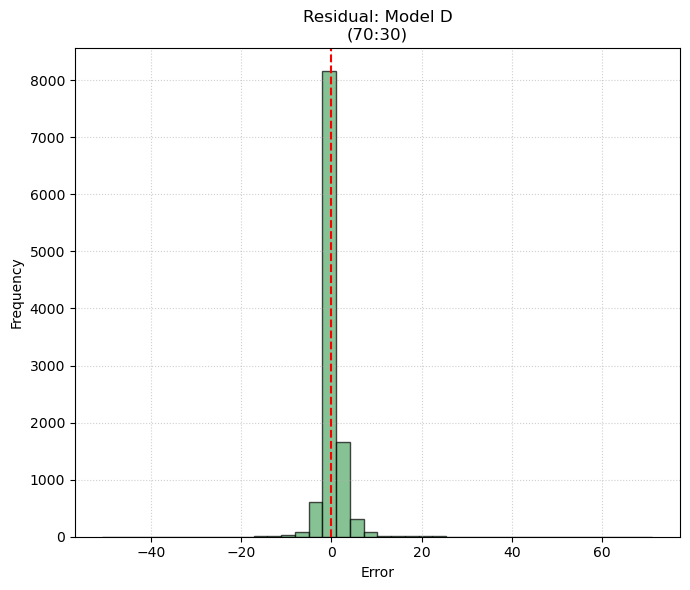

[INFO] 
RUNNING SPLIT 90:10
[INFO] Training Model A...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


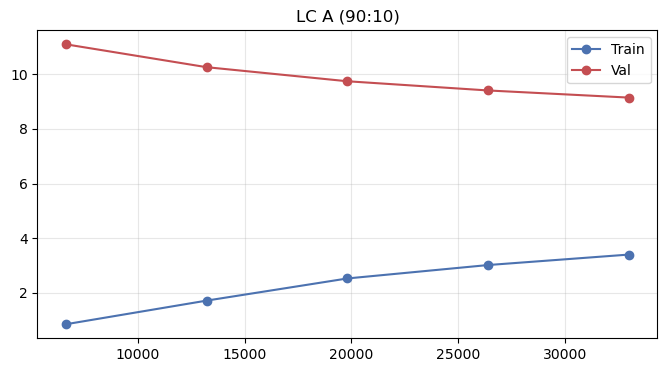

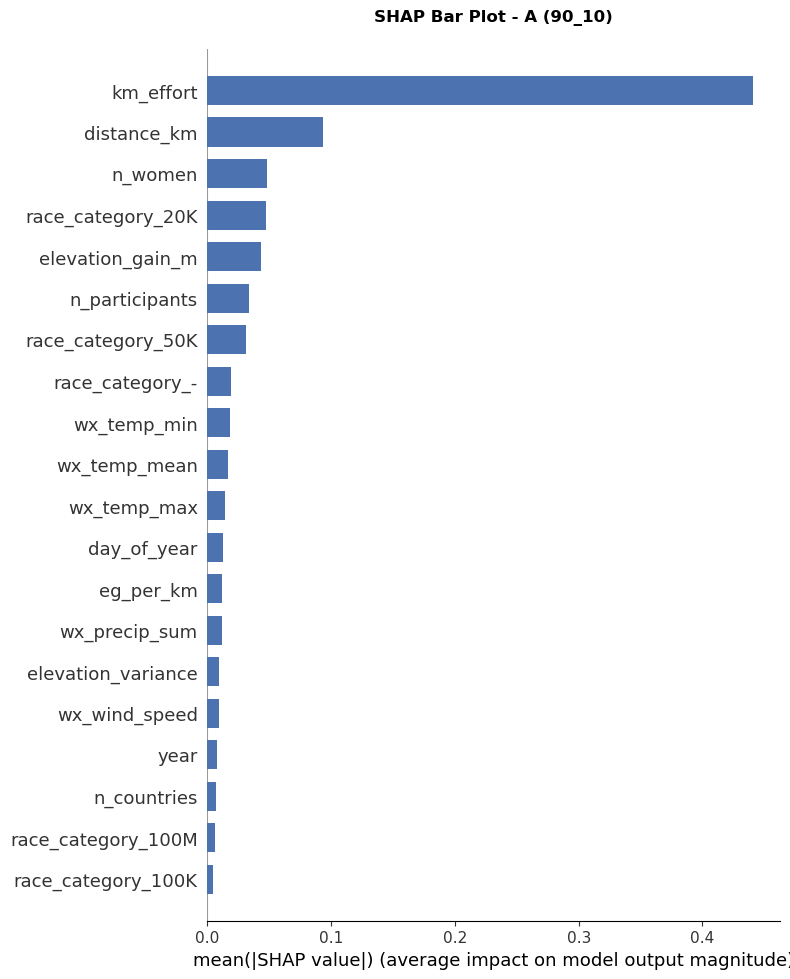

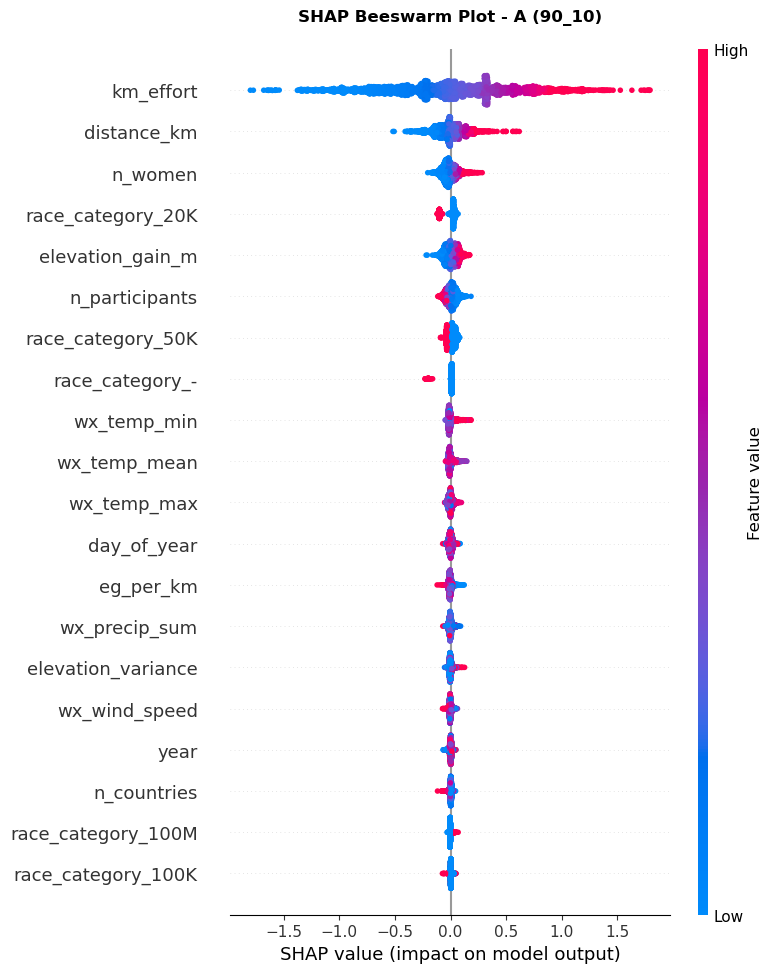

[INFO] Training Model B...


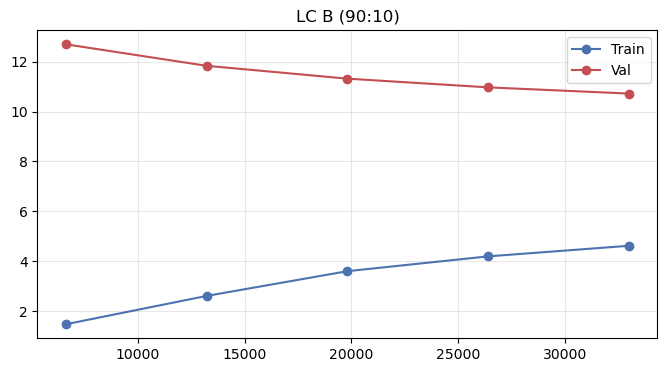

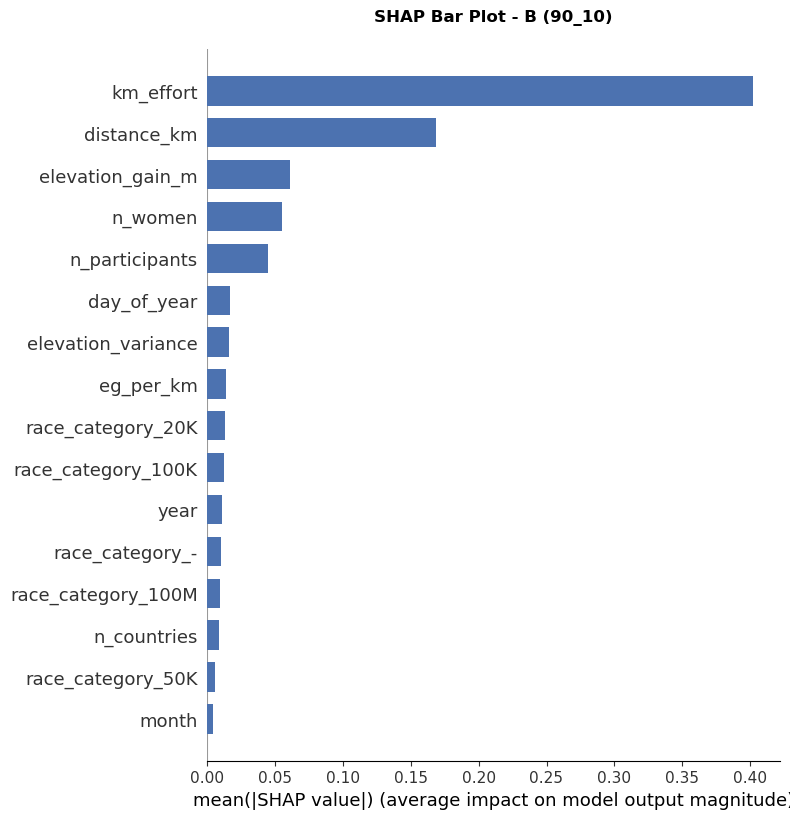

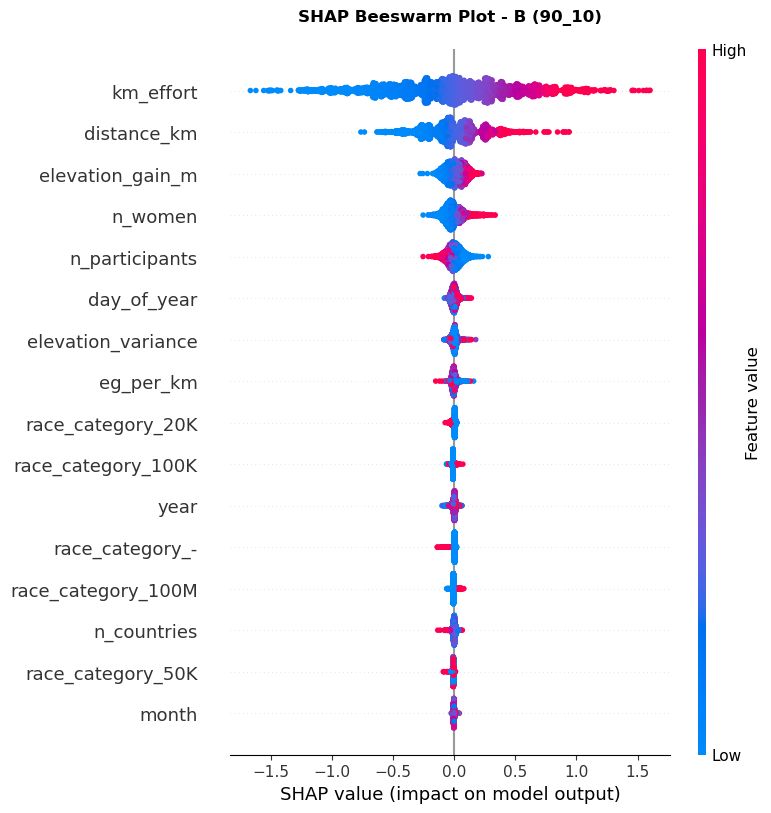

[INFO] Training Model D...


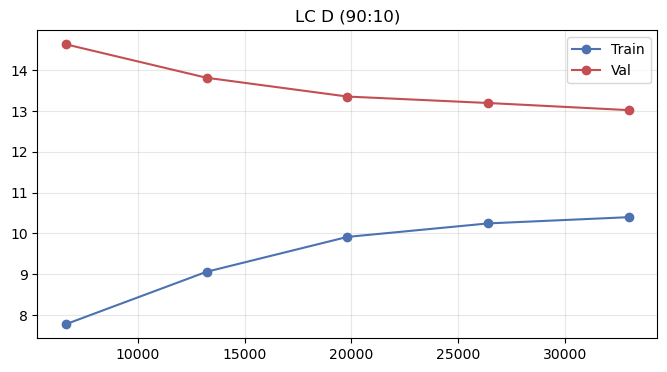

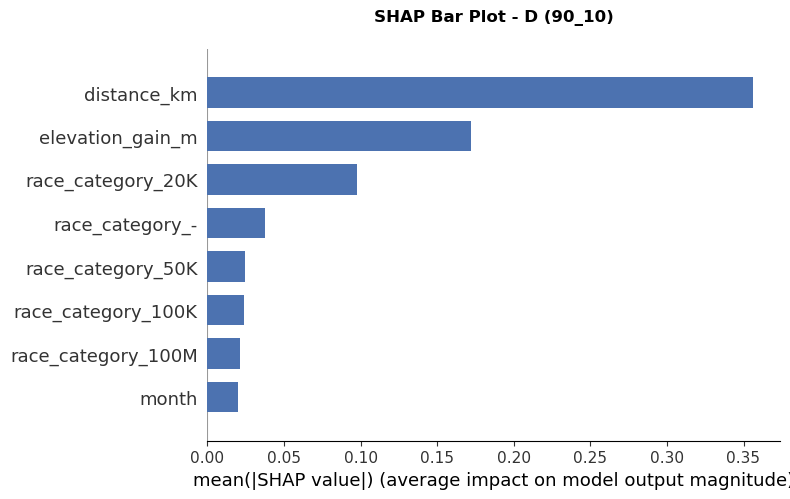

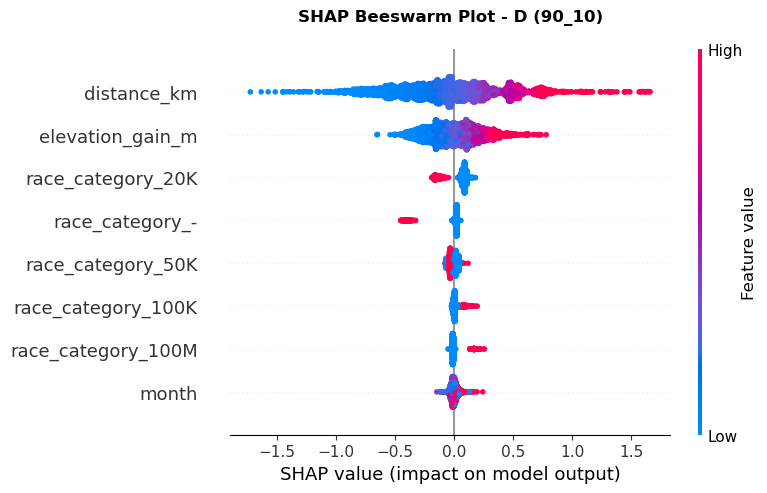

[INFO] Training Model C...


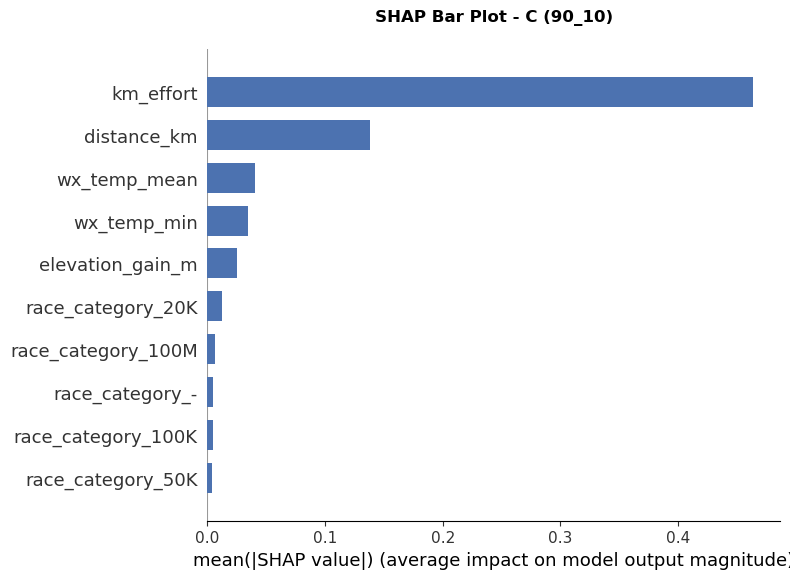

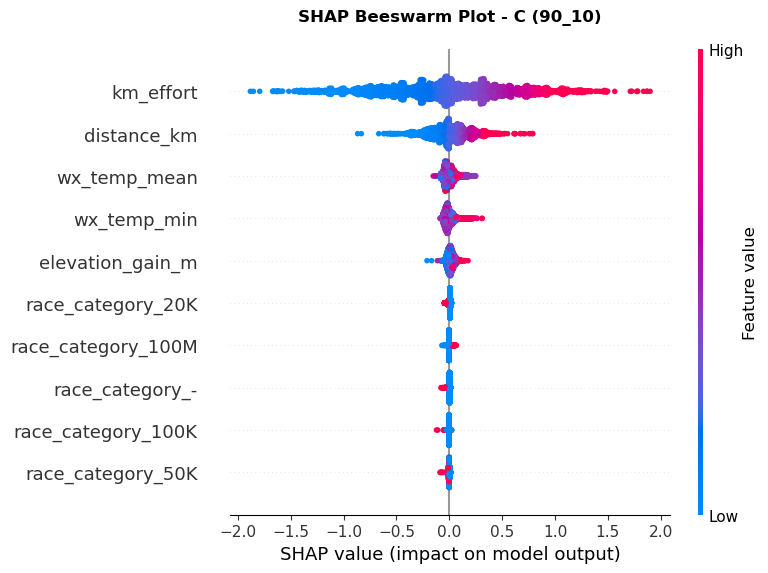

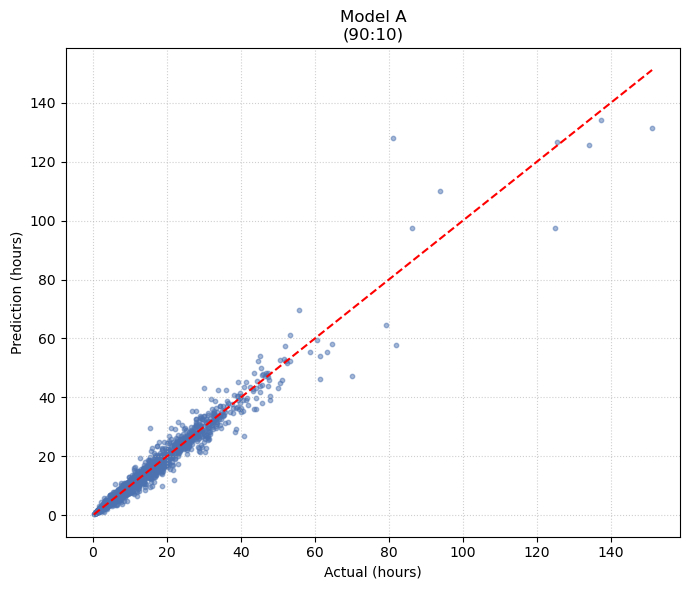

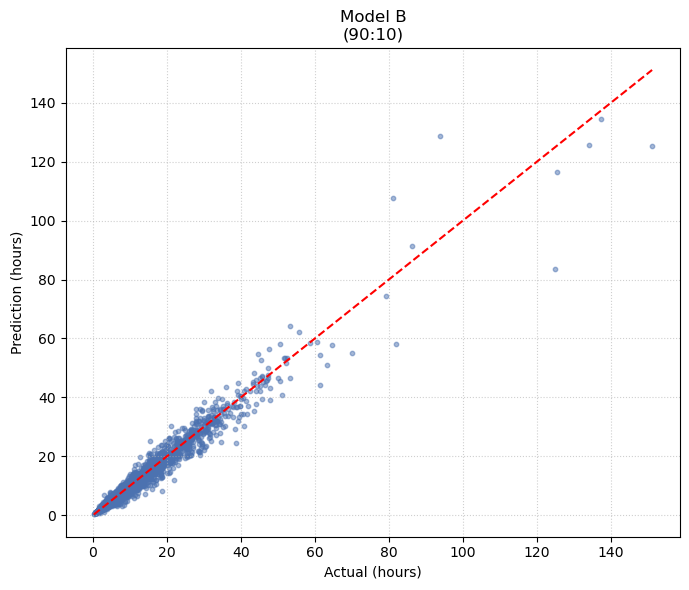

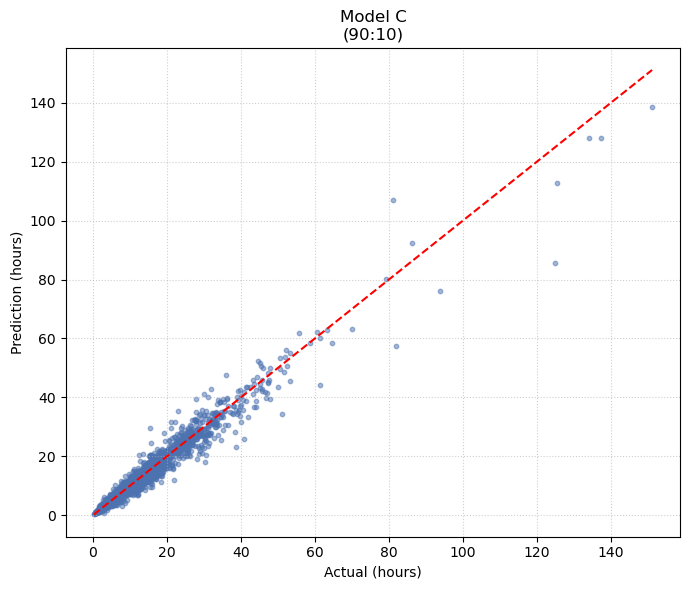

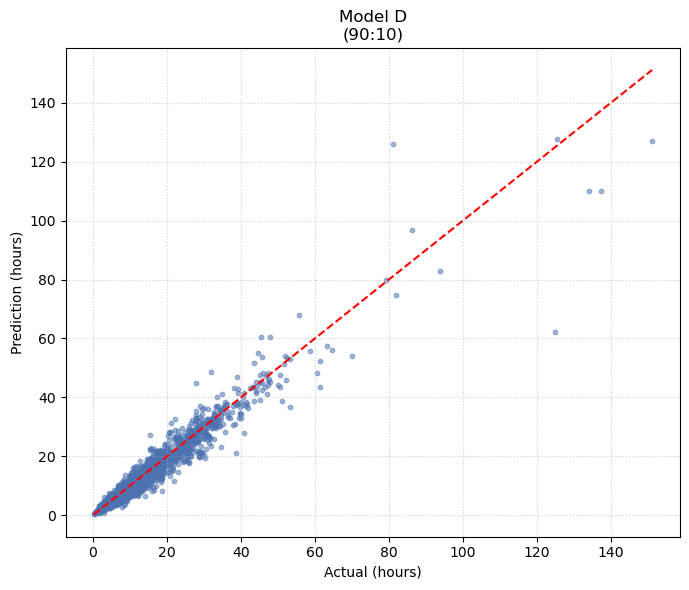

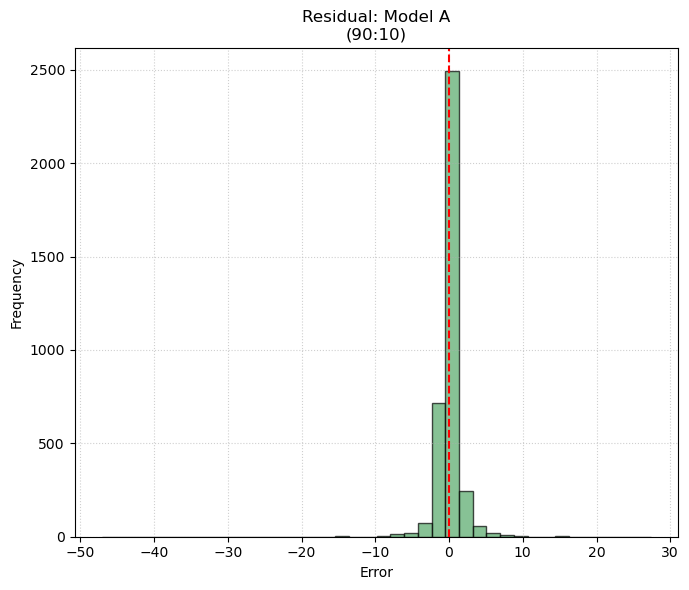

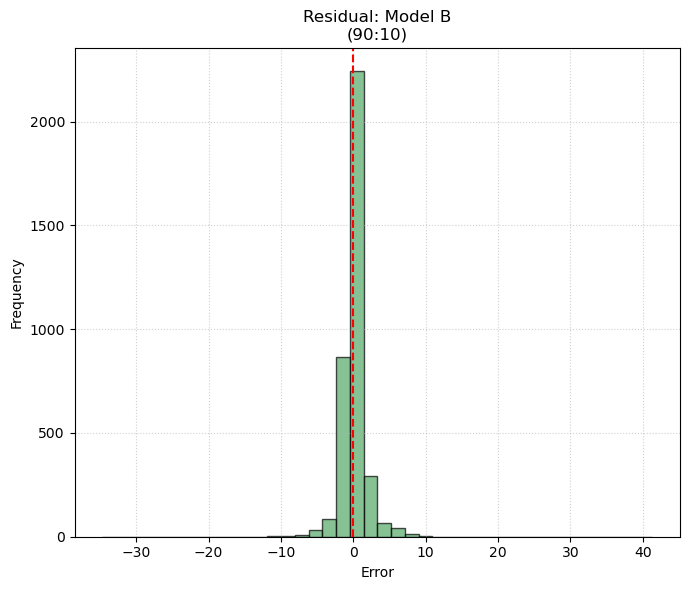

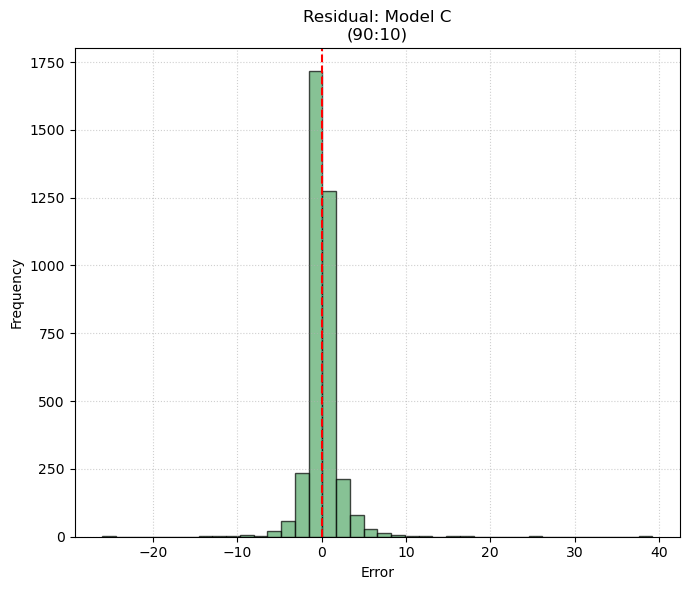

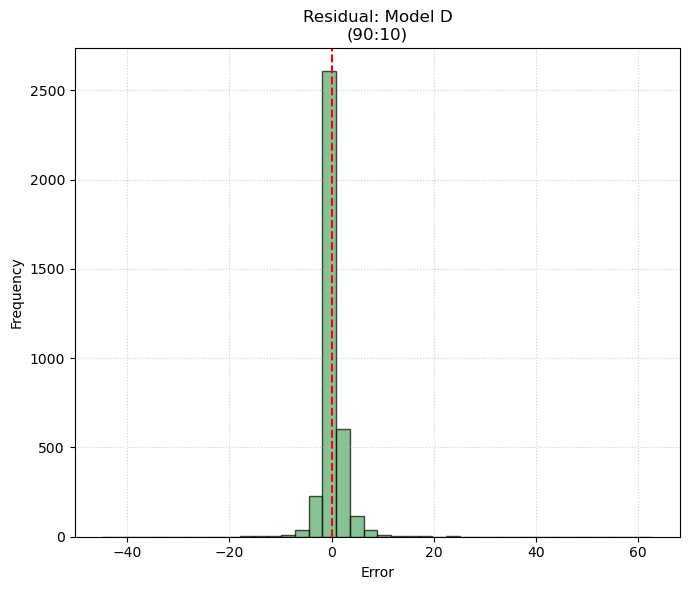

[INFO] ✅ SELESAI! Semua model (.pkl), grafik, dan metrik (Per Fold) telah aman.


,Split,Model,MAE,RMSE,R2,MAPE(%)
0,80:20,Model A (Cuaca),0.949655,2.178430,0.956083,8.870318
1,80:20,Model B (Tanpa Cuaca),1.093304,2.362639,0.948341,10.517296
2,80:20,Model C (Top 10),1.110346,2.350326,0.948879,10.628389
3,80:20,Model D (Input Minimal),1.317279,2.666939,0.934178,12.813252
4,70:30,Model A (Cuaca),0.970713,2.284047,0.952421,9.142359
5,70:30,Model B (Tanpa Cuaca),1.105820,2.404979,0.947250,10.782082
6,70:30,Model C (Top 10),1.126042,2.389493,0.947927,10.822136
7,70:30,Model D (Input Minimal),1.345161,2.943308,0.920991,12.984415
8,90:10,Model A (Cuaca),0.894254,1.910382,0.965695,8.615129
9,90:10,Model B (Tanpa Cuaca),1.033595,2.064700,0.959929,10.290003


In [6]:

def main(cfg: Config):
    log("🚀 Memulai Eksperimen Final Boss...")
    df = anti_leakage_filter(feature_engineering(clean_data(pd.read_csv(cfg.DATA_PATH))))
    y_full = df["mean_finish_time"].values
    X_full = df.drop(columns=["mean_finish_time"], errors="ignore")
    strata_full = pd.qcut(y_full, q=cfg.N_STRATA_BINS, labels=False, duplicates="drop")

    comparison_summary = []
    cv_per_fold_summary = []

    for t_size in cfg.SPLIT_SCENARIOS:
        split_label = f"{int((1-t_size)*100)}_{int(t_size*100)}"
        split_title = split_label.replace('_', ':')
        log(f"\nRUNNING SPLIT {split_title}")

        sss = StratifiedShuffleSplit(n_splits=1, test_size=t_size, random_state=cfg.RANDOM_STATE)
        tr_idx, te_idx = next(sss.split(X_full, strata_full))
        X_tr, X_te = X_full.iloc[tr_idx].copy(), X_full.iloc[te_idx].copy()
        y_tr, y_te = y_full[tr_idx], y_full[te_idx]
        
        # GANTI BARIS LAMA YANG PAKE LAMBDA DENGAN INI:
        target_tf = {"fwd": fwd_log, "inv": inv_exp} if cfg.ENABLE_LOG_TARGET else {"fwd": fwd_none, "inv": inv_none}
        keep_A, keep_B, keep_D = get_scenario_feature_lists(X_tr)

        # --- MODEL A ---
        log("Training Model A...")
        pipe_A, cat_A, num_A = build_pipeline(keep_A, cfg.RANDOM_STATE, cfg.TREE_METHOD)
        best_est_A, best_params_A = tune_scenario_A(TransformedTargetEstimator(pipe_A, **target_tf), X_tr[keep_A], y_tr, strata_full[tr_idx], cfg)
        joblib.dump(best_est_A, f"{cfg.OUT_DIR}/Model_A_{split_label}.pkl")
        
        pred_A = best_est_A.predict(X_te[keep_A]); metrics_A = compute_metrics(y_te, pred_A)
        cv_per_fold_summary.extend(get_cv_per_fold_metrics(best_est_A, X_tr[keep_A], y_tr, strata_full[tr_idx], cfg, "Model A", split_title))
        
        best_model_params = {k.replace("regressor__model__", ""): v for k, v in best_params_A.items() if "regressor__model__" in k}
        plot_lc(learning_curve_mape(best_est_A, X_tr[keep_A], y_tr, strata_full[tr_idx], cfg), f"{cfg.OUT_DIR}/LC_A_{split_label}.png", f"LC A ({split_title})")
        pre_A = best_est_A.regressor_.named_steps["pre"]
        f_names_A = (list(pre_A.named_transformers_["cat"].get_feature_names_out(cat_A)) if cat_A else []) + num_A
        run_dual_shap(best_est_A.regressor_.named_steps["model"], pre_A.transform(X_te[keep_A]), f_names_A, split_label, "A", cfg)

        # --- MODEL B & D ---
        def train_and_visual(features, name):
            log(f"Training Model {name}...")
            p, c_cols, n_cols = build_pipeline(features, cfg.RANDOM_STATE, cfg.TREE_METHOD)
            p.named_steps["model"].set_params(**best_model_params)
            est = TransformedTargetEstimator(p, **target_tf).fit(X_tr[features], y_tr)
            joblib.dump(est, f"{cfg.OUT_DIR}/Model_{name}_{split_label}.pkl")
            
            pred = est.predict(X_te[features]); metrics = compute_metrics(y_te, pred)
            cv_per_fold_summary.extend(get_cv_per_fold_metrics(est, X_tr[features], y_tr, strata_full[tr_idx], cfg, f"Model {name}", split_title))
            
            plot_lc(learning_curve_mape(est, X_tr[features], y_tr, strata_full[tr_idx], cfg), f"{cfg.OUT_DIR}/LC_{name}_{split_label}.png", f"LC {name} ({split_title})")
            pre = est.regressor_.named_steps["pre"]
            f_names = (list(pre.named_transformers_["cat"].get_feature_names_out(c_cols)) if c_cols else []) + n_cols
            run_dual_shap(est.regressor_.named_steps["model"], pre.transform(X_te[features]), f_names, split_label, name, cfg)
            return pred, metrics

        pred_B, metrics_B = train_and_visual(keep_B, "B")
        pred_D, metrics_D = train_and_visual(keep_D, "D")

        # --- MODEL C ---
        log("Training Model C...")
        imp_df = get_gain_importance(best_est_A.regressor_.named_steps["model"], f_names_A)
        topN_names = imp_df["feature"].head(cfg.TOP_N).tolist()
        X_tr_C = pd.DataFrame(pre_A.transform(X_tr[keep_A]), columns=f_names_A)[topN_names]
        X_te_C = pd.DataFrame(pre_A.transform(X_te[keep_A]), columns=f_names_A)[topN_names]
        est_C = TransformedTargetEstimator(XGBRegressor(**best_model_params), **target_tf).fit(X_tr_C, y_tr)
        joblib.dump(est_C, f"{cfg.OUT_DIR}/Model_C_{split_label}.pkl")
        
        pred_C = est_C.predict(X_te_C); metrics_C = compute_metrics(y_te, pred_C)
        cv_per_fold_summary.extend(get_cv_per_fold_metrics(est_C, X_tr_C, y_tr, strata_full[tr_idx], cfg, "Model C", split_title))
        run_dual_shap(est_C.regressor_, X_te_C.values, topN_names, split_label, "C", cfg)

        # GRID PLOTS
        preds_dict = {"Model A": pred_A, "Model B": pred_B, "Model C": pred_C, "Model D": pred_D}
        plot_model_comparison_grid(y_te, preds_dict, split_title, f"{cfg.OUT_DIR}/Grid_P_{split_label}.png", cfg.SAVE_FIG_DPI, False)
        plot_model_comparison_grid(y_te, preds_dict, split_title, f"{cfg.OUT_DIR}/Grid_R_{split_label}.png", cfg.SAVE_FIG_DPI, True)

        comparison_summary.extend([
            {"Split": split_title, "Model": "Model A (Cuaca)", **metrics_A},
            {"Split": split_title, "Model": "Model B (Tanpa Cuaca)", **metrics_B},
            {"Split": split_title, "Model": f"Model C (Top {cfg.TOP_N})", **metrics_C},
            {"Split": split_title, "Model": "Model D (Input Minimal)", **metrics_D},
        ])

    # EXPORT
    pd.DataFrame(comparison_summary).to_csv(f"{cfg.OUT_DIR}/Final_Metrics.csv", index=False)
    pd.DataFrame(cv_per_fold_summary).to_csv(f"{cfg.OUT_DIR}/CV_Per_Fold_Results.csv", index=False)
    log("✅ SELESAI! Semua model (.pkl), grafik, dan metrik (Per Fold) telah aman.")
    return pd.DataFrame(comparison_summary)

# JALANKAN
final_results = main(Config())
display(final_results)